In [2]:
pip install easyocr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 19.4 MB/s eta 0:00:00


[INFO] Detected Payees: ['Abhilah_Reddy']


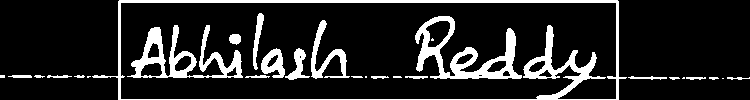

In [7]:
import cv2
import numpy as np
import imutils
from imutils.contours import sort_contours
from tensorflow.keras.models import load_model
from easyocr import Reader

# Load pre-trained model
model = load_model(r"/content/handwriting_model.h5")  # Replace with the correct path to your model

# Initialize EasyOCR reader
reader = Reader(['en'], gpu=True)

def get_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def remove_noise(image):
    return cv2.GaussianBlur(image, (5, 5), 0)

def thresholding(image):
    return cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]

def cropping(image):
    # Adjust cropping region if needed
    return image[200:300, 500:1250]

def cleanup_text(text):
    return text.strip().replace("\n", " ").replace("\r", "")

def process_and_ocr(image, model, reader):
    """
    Processes the input image, performs OCR using EasyOCR for printed text detection,
    and returns the detected results.
    """
    # Step 1: Preprocessing
    gray = get_grayscale(image)
    denoised = remove_noise(gray)
    thresh = thresholding(denoised)
    cropped = cropping(thresh)

    # Step 2: EasyOCR for printed text recognition
    payees = []
    results = reader.readtext(cropped, detail=1)  # Get detailed output with bounding boxes
    for (bbox, text, prob) in results:
        text = cleanup_text(text)
        if prob > 0.5:  # Confidence threshold
            payees.append(text)  # Append detected text
            # Draw bounding box and text on the image
            cv2.rectangle(cropped, (int(bbox[0][0]), int(bbox[0][1])), (int(bbox[2][0]), int(bbox[2][1])), (255, 0, 0), 2)
            cv2.putText(cropped, text, (int(bbox[0][0]), int(bbox[0][1]) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    return payees, cropped

# Path to input image
image_path = '/content/X_056.jpeg'  # Replace with the path to your uploaded image

image = cv2.imread(image_path)

if image is None:
    print(f"[ERROR] Could not load image from {image_path}. Check the path.")
else:
    # Call the OCR function
    payees, processed_image = process_and_ocr(image, model, reader)

    # Display the results
    print("[INFO] Detected Payees:", payees)

    # Use cv2.imshow to display the processed image locally
    from google.colab.patches import cv2_imshow
    cv2_imshow(processed_image)
